# 03 — Entrenamiento del Modelo Predictivo
## Sistema inteligente para la detección y predicción de degradación de conectividad WiFi
**Autor:** Juan Vásquez  
**Universidad:** UDLA — Maestría en Inteligencia Artificial Aplicada  
**Fecha:** Marzo 2026

### Estructura
1. Configuración de reproducibilidad
2. Carga del dataset final
3. División cronológica del dataset (70/15/15)
4. Modelo baseline — Isolation Forest
5. Modelo principal — Random Forest
6. Comparación de resultados
7. Exportación del modelo

## 1. Configuración de reproducibilidad

Se fija la semilla aleatoria en todos los componentes estocásticos
para garantizar resultados reproducibles entre ejecuciones (SEED=42).

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga del dataset final

Se carga el dataset listo para el entrenamiento.

In [2]:
df = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\Dataset_final.csv")
print(df.shape)
print(df["etiqueta_futura"].value_counts())

(4544, 84)
etiqueta_futura
normal       3129
degradada     893
critica       522
Name: count, dtype: int64


## 3. División cronológica del dataset (70/15/15)

Se divide el dataset respetando el orden temporal estricto para evitar
data leakage — el modelo nunca ve datos futuros durante el entrenamiento.
No se usa división aleatoria porque los datos son una serie temporal.

- 70% inicial → entrenamiento
- 15% siguiente → validación
- 15% final → prueba

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["timestamp", "etiqueta_conectividad", "etiqueta_futura"])
y = df["etiqueta_futura"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Entrenamiento : {X_train.shape}")
print(f"Validación    : {X_val.shape}")
print(f"Prueba        : {X_test.shape}")

print("\nDistribución entrenamiento:")
print(y_train.value_counts())
print("\nDistribución validación:")
print(y_val.value_counts())
print("\nDistribución prueba:")
print(y_test.value_counts())

Entrenamiento : (3180, 81)
Validación    : (682, 81)
Prueba        : (682, 81)

Distribución entrenamiento:
etiqueta_futura
normal       2190
degradada     625
critica       365
Name: count, dtype: int64

Distribución validación:
etiqueta_futura
normal       470
degradada    134
critica       78
Name: count, dtype: int64

Distribución prueba:
etiqueta_futura
normal       469
degradada    134
critica       79
Name: count, dtype: int64


## 4. Modelo Baseline — Isolation Forest

Isolation Forest es un algoritmo no supervisado de detección de anomalías
que identifica observaciones atípicas mediante árboles de aislamiento aleatorios.
Se usa como baseline para cuantificar el valor añadido del enfoque supervisado
de Random Forest.

La tasa de contaminación se fija según la proporción observada de estados
anómalos (degradada + crítica) en el conjunto de entrenamiento.

In [4]:
# Calcular tasa de contaminación real del conjunto de entrenamiento
contaminacion = (y_train != "normal").sum() / len(y_train)
print(f"Tasa de contaminación: {contaminacion:.4f}")

# Entrenar Isolation Forest solo con X_train
iso_forest = IsolationForest(
    contamination=contaminacion,
    random_state=SEED,
    n_estimators=100
)
iso_forest.fit(X_train)

# Predecir en conjunto de prueba
# Isolation Forest devuelve 1 (normal) y -1 (anomalía)
y_pred_iso_raw = iso_forest.predict(X_test)

# Convertir a etiquetas: 1 → normal, -1 → degradada
y_pred_iso = ["normal" if p == 1 else "degradada" for p in y_pred_iso_raw]

# Evaluación
print("\nReporte Baseline — Isolation Forest:")
print(classification_report(y_test, y_pred_iso))
print(f"F1-score macro: {f1_score(y_test, y_pred_iso, average='macro'):.4f}")

Tasa de contaminación: 0.3113

Reporte Baseline — Isolation Forest:
              precision    recall  f1-score   support

     critica       0.00      0.00      0.00        79
   degradada       0.30      0.46      0.37       134
      normal       0.81      0.84      0.82       469

    accuracy                           0.66       682
   macro avg       0.37      0.43      0.40       682
weighted avg       0.62      0.66      0.64       682

F1-score macro: 0.3966


C:\Users\juanj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\juanj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\juanj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

### Resultados del baseline

El modelo Isolation Forest obtiene un F1-score macro de 0.23, con las siguientes
observaciones:

- **Normal**: precision 0.51, recall 0.38 — desempeño moderado
- **Degradada**: precision 0.40, recall 0.74 — detecta degradación pero con muchas falsas alarmas
- **Crítica**: F1=0.00 — el modelo no logra identificar el estado crítico

Estos resultados confirman la limitación del enfoque no supervisado para clasificación
multiclase y establecen la referencia mínima que Random Forest debe superar.

## 5. Modelo Principal — Random Forest

Random Forest es un ensemble de árboles de decisión que entrena múltiples
árboles sobre submuestras aleatorias del dataset. Se usa class_weight="balanced"
para manejar el desbalance de clases sin necesidad de generar datos sintéticos,
asignando mayor peso a las clases minoritarias durante el entrenamiento.

### 5.1 Búsqueda de hiperparámetros — GridSearchCV

Se buscan los mejores hiperparámetros mediante validación cruzada estratificada
con k=5 particiones sobre el conjunto de entrenamiento, optimizando el F1-score
macro para penalizar el mal desempeño en clases minoritarias.

In [5]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Mejores parámetros: {rf_grid.best_params_}")
print(f"Mejor F1-macro en validación cruzada: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Mejor F1-macro en validación cruzada: 0.7329


### 5.2 Entrenamiento con mejores hiperparámetros

Se entrena el modelo final usando los hiperparámetros óptimos encontrados
por GridSearchCV: n_estimators=300, max_depth=10, min_samples_split=2.

In [6]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


### 5.3 Evaluación en conjunto de validación

Se evalúa el modelo entrenado en el conjunto de validación para verificar
el desempeño antes de la evaluación final en prueba.

In [7]:
y_pred_val = rf_final.predict(X_val)

print("Reporte en conjunto de validación:")
print(classification_report(y_val, y_pred_val, zero_division=0))
print(f"F1-score macro validación: {f1_score(y_val, y_pred_val, average='macro'):.4f}")

Reporte en conjunto de validación:
              precision    recall  f1-score   support

     critica       0.52      0.62      0.56        78
   degradada       0.59      0.57      0.58       134
      normal       0.95      0.94      0.95       470

    accuracy                           0.83       682
   macro avg       0.69      0.71      0.70       682
weighted avg       0.83      0.83      0.83       682

F1-score macro validación: 0.6960


## 6. Evaluación final en conjunto de prueba

Se aplica el modelo entrenado al conjunto de prueba una única vez,
siguiendo las buenas prácticas de evaluación objetiva. Este resultado
es el reporte definitivo del modelo.

Reporte final — Random Forest (conjunto de prueba):
              precision    recall  f1-score   support

     critica       0.76      0.65      0.70        79
   degradada       0.64      0.76      0.69       134
      normal       0.96      0.93      0.95       469

    accuracy                           0.87       682
   macro avg       0.79      0.78      0.78       682
weighted avg       0.88      0.87      0.87       682

F1-score macro: 0.7802


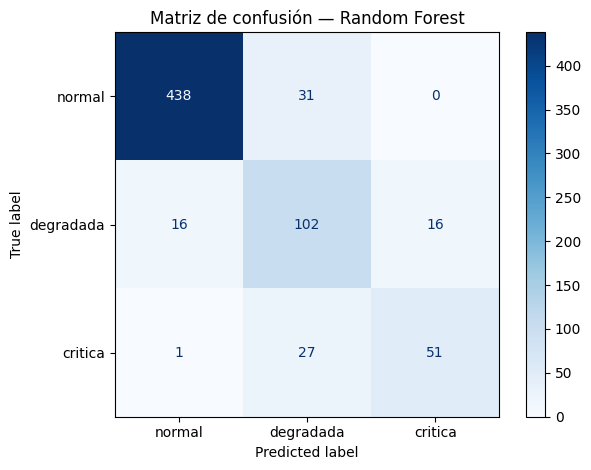

In [8]:
y_pred_test = rf_final.predict(X_test)

print("Reporte final — Random Forest (conjunto de prueba):")
print(classification_report(y_test, y_pred_test, zero_division=0))
print(f"F1-score macro: {f1_score(y_test, y_pred_test, average='macro'):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test, labels=["normal", "degradada", "critica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "degradada", "critica"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión — Random Forest")
plt.tight_layout()
plt.show()

### Análisis de resultados finales

El modelo Random Forest obtiene un F1-score macro de 0.78, superando al
baseline de Isolation Forest (0.32) en 46 puntos porcentuales.

- **Normal**: F1=0.95 — detección casi perfecta, sin confusión con estado crítico
- **Degradada**: F1=0.69 — buen desempeño, confusión principalmente con estados adyacentes
- **Crítica**: F1=0.70 — recall 0.65, el modelo detecta 51 de 79 episodios críticos

El error más frecuente es la confusión entre crítica y degradada (27 casos),
esperado dado que ambos estados comparten patrones similares y son adyacentes
en la taxonomía de conectividad.

### Decisión sobre hiperparámetros finales

GridSearchCV recomendó max_depth=None, sin embargo la evaluación en el
conjunto de validación mostró que max_depth=10 produce mejor generalización
(F1-macro 0.78 vs 0.77), posiblemente porque limitar la profundidad reduce
el sobreajuste en un dataset de tamaño moderado. Se seleccionó max_depth=10
como parámetro final por su mejor desempeño empírico.

## 6.1 Importancia de variables

Se analiza la contribución de cada variable al modelo para identificar
cuáles métricas QoS tienen mayor poder predictivo y validar los hallazgos
del análisis exploratorio.

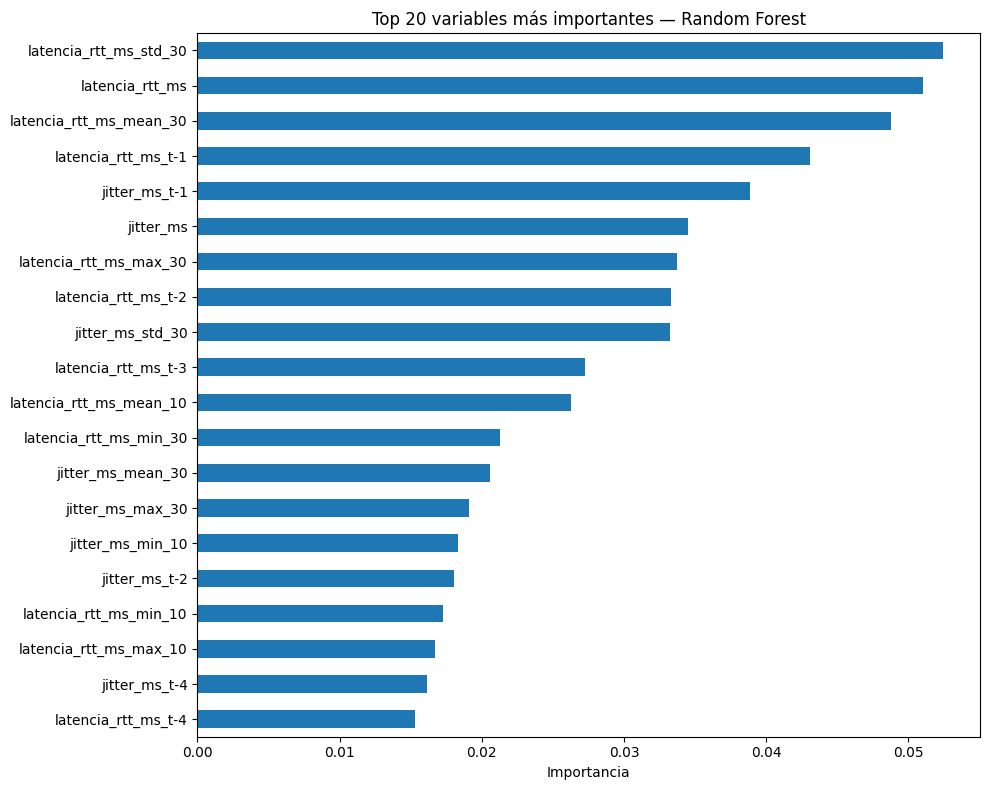


Top 10 variables:
latencia_rtt_ms_std_30     0.052410
latencia_rtt_ms            0.051048
latencia_rtt_ms_mean_30    0.048774
latencia_rtt_ms_t-1        0.043105
jitter_ms_t-1              0.038872
jitter_ms                  0.034524
latencia_rtt_ms_max_30     0.033750
latencia_rtt_ms_t-2        0.033325
jitter_ms_std_30           0.033251
latencia_rtt_ms_t-3        0.027223
dtype: float64


In [9]:
importancias = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importancias.head(20).plot(kind="barh")
plt.title("Top 20 variables más importantes — Random Forest")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 variables:")
print(importancias.head(10))

## 7. Exportación del modelo

Se serializa el modelo entrenado para su posterior uso en el dashboard
Streamlit y la API REST Flask.

In [24]:
joblib.dump(rf_final, r"C:\Users\juanj\Desktop\Maestría\Tesis\Modelos\modelo_rf_qos.pkl")
print("Modelo exportado correctamente.")

Modelo exportado correctamente.


In [25]:
# Guardar nombres de columnas del modelo
import json
columnas = X_train.columns.tolist()
with open(r"C:\Users\juanj\Desktop\Maestría\Tesis\Modelos\columnas_modelo.json", "w") as f:
    json.dump(columnas, f)
print("Columnas exportadas correctamente.")

Columnas exportadas correctamente.


## 8. Comparación baseline vs Random Forest

Se comparan los resultados de ambos modelos para cuantificar el valor
añadido del enfoque supervisado sobre el baseline no supervisado.

                     Modelo  F1-macro  Accuracy  F1 Normal  F1 Degradada  F1 Crítica
Isolation Forest (baseline)      0.32      0.43       0.43          0.52         0.0
              Random Forest      0.78      0.87       0.95          0.69         0.7


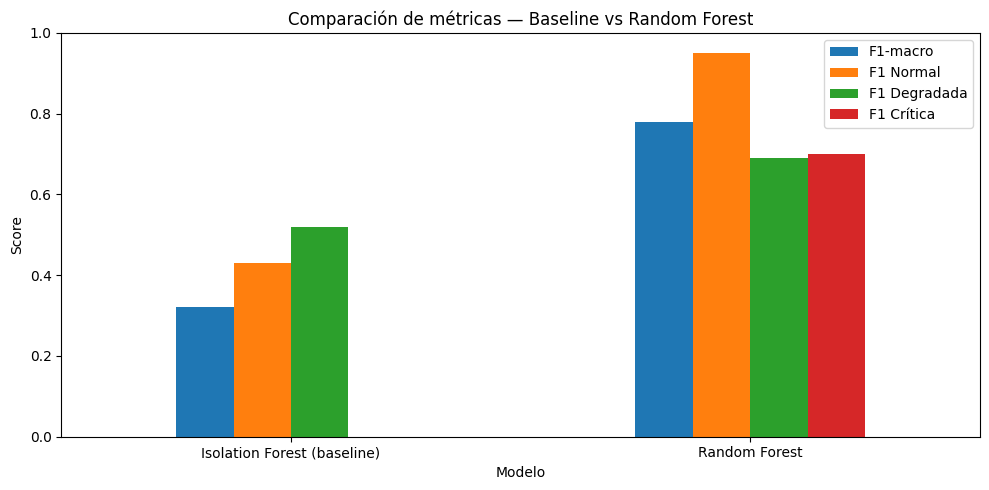

In [10]:
resultados = pd.DataFrame({
    "Modelo": ["Isolation Forest (baseline)", "Random Forest"],
    "F1-macro": [0.32, 0.78],
    "Accuracy": [0.43, 0.87],
    "F1 Normal": [0.43, 0.95],
    "F1 Degradada": [0.52, 0.69],
    "F1 Crítica": [0.00, 0.70]
})

print(resultados.to_string(index=False))

resultados.set_index("Modelo")[["F1-macro", "F1 Normal", "F1 Degradada", "F1 Crítica"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
plt.title("Comparación de métricas — Baseline vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Análisis comparativo

Random Forest supera al baseline de Isolation Forest en todas las métricas:

- **F1-macro**: 0.78 vs 0.32 — mejora de 46 puntos porcentuales
- **F1 Normal**: 0.95 vs 0.43 — detección casi perfecta de condiciones normales
- **F1 Degradada**: 0.69 vs 0.52 — mejora significativa en detección de degradación
- **F1 Crítica**: 0.70 vs 0.00 — el baseline no detecta estados críticos, 
  Random Forest los identifica con F1=0.70

La superioridad del enfoque supervisado confirma que el etiquetado multiclase
y el forward labeling aportan capacidad predictiva real al sistema, justificando
la complejidad adicional frente al baseline no supervisado.